# Project 2 - Notebook 4: Regression Analysis

The goal Notebook:


- Perform logistic regression analysis to model the relationship between potential risk factors and leukemia status (Leukemia_Status).

- Identify statistically significant risk factors in predicting leukemia status.

- Estimating Odds Ratio (OR) to measure the strength of risk factor association.

- Create professional visualization for logistic regression results! (Odds Ratio, Confidence Interval, Significance)

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid') # The white grid style is cleaner and more modern
plt.rcParams['figure.figsize'] = (12, 7) # Enlarged figure size, wider landscape
plt.rcParams['font.size'] = 14 # Default font size enlarged for more clarity
plt.rcParams['axes.titlesize'] = 16 # Axes title size enlarged
plt.rcParams['axes.labelsize'] = 14 # Axes label size enlarged
plt.rcParams['xtick.labelsize'] = 12 # X axis label tick size enlarged
plt.rcParams['ytick.labelsize'] = 12 # Y axis label tick size
plt.rcParams['legend.fontsize'] = 12 # Legend font size
plt.rcParams['figure.titleweight'] = 'bold' # Bold figure title
plt.rcParams['axes.titleweight'] = 'bold' # Axes title bold

## Load Data

In [3]:
df = pd.read_csv('../data/luekemia_prepared_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Leukemia_Status       143194 non-null  object 
 1   Smoking_Status        143194 non-null  object 
 2   Family_History        143194 non-null  object 
 3   Genetic_Mutation      143194 non-null  object 
 4   Ethnicity             143194 non-null  object 
 5   Socioeconomic_Status  143194 non-null  object 
 6   WBC_Count             143194 non-null  int64  
 7   Bone_Marrow_Blasts    143194 non-null  int64  
 8   Age                   143194 non-null  int64  
 9   RBC_Count             143194 non-null  float64
 10  BMI                   143194 non-null  float64
dtypes: float64(2), int64(3), object(6)
memory usage: 12.0+ MB


## Univariate Logistics Regression Analysis

In [4]:
# encode column has category/object data type using ONE-HOT ENCODING
cat_col = [
    "Smoking_Status",
    "Family_History",
    "Genetic_Mutation",
    "Ethnicity",
    "Socioeconomic_Status"
]
df = pd.get_dummies(df, columns=cat_col, drop_first=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143194 entries, 0 to 143193
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Leukemia_Status              143194 non-null  object 
 1   WBC_Count                    143194 non-null  int64  
 2   Bone_Marrow_Blasts           143194 non-null  int64  
 3   Age                          143194 non-null  int64  
 4   RBC_Count                    143194 non-null  float64
 5   BMI                          143194 non-null  float64
 6   Smoking_Status_Yes           143194 non-null  bool   
 7   Family_History_Yes           143194 non-null  bool   
 8   Genetic_Mutation_Yes         143194 non-null  bool   
 9   Ethnicity_Ethnic_Group_B     143194 non-null  bool   
 10  Ethnicity_Ethnic_Group_C     143194 non-null  bool   
 11  Socioeconomic_Status_Low     143194 non-null  bool   
 12  Socioeconomic_Status_Medium  143194 non-null  bool   
dtyp

In [5]:
# maping Leukemia_Status to 1 and 0
df['Leukemia_Status'] = df['Leukemia_Status'].map({'Positive': 1, 'Negative': 0})

In [6]:
print("List column names df DataFrame after ONE-HOT ENCODING:")
print(df.columns.tolist()) 
print("========================================")


List column names df DataFrame after ONE-HOT ENCODING:
['Leukemia_Status', 'WBC_Count', 'Bone_Marrow_Blasts', 'Age', 'RBC_Count', 'BMI', 'Smoking_Status_Yes', 'Family_History_Yes', 'Genetic_Mutation_Yes', 'Ethnicity_Ethnic_Group_B', 'Ethnicity_Ethnic_Group_C', 'Socioeconomic_Status_Low', 'Socioeconomic_Status_Medium']


In [7]:
#  variable to save visualization
list_univariate = []
risk_factor_cols = [
        'WBC_Count', 
        'Bone_Marrow_Blasts', 
        'Age', 
        'RBC_Count', 
        'BMI', 
        'Smoking_Status_Yes', 
        'Family_History_Yes', 
        'Genetic_Mutation_Yes', 
        'Ethnicity_Ethnic_Group_B', 
        'Ethnicity_Ethnic_Group_C', 
        'Socioeconomic_Status_Low', 
        'Socioeconomic_Status_Medium'
    ]

In [8]:
# looping risk factor for univariate regression
for risk_factor in risk_factor_cols:
    reg_formula = "Leukemia_Status ~ " + risk_factor
    # train/fit model regression logistic
    regression_univariate_model = smf.logit(reg_formula, data=df).fit()
    print(f"Summary of Univariate Logistic Regression Model for Risk Factors: {risk_factor}")
    
    print(regression_univariate_model.summary())
    print("========================================")
    
    if risk_factor not in regression_univariate_model.params.keys():
        print(f"WARNING: Risk Factor: {risk_factor} skip from univariate regression cause zero variancy")
        print("========================================")
        continue

    print(f"Keys in regression_univariate_model.params: {regression_univariate_model.params.keys()}")
    print(f"current risk factor: {risk_factor}")
    
    # extract coeficient regression & confidence level
    coef_reg = regression_univariate_model.params[risk_factor]
    confidence_reg = regression_univariate_model.conf_int().loc[risk_factor]
    
    # calculate odd ratio & confidence interval
    odds_ratio = np.exp(coef_reg)
    lower_ci = np.exp(confidence_reg[0])
    upper_ci = np.exp(confidence_reg[1])
    
    # save data for visualization
    list_univariate.append({
        "Risk Factor": risk_factor,
        "Odds Ratio": odds_ratio,
        "Lower CI": lower_ci,
        "Upper CI": upper_ci
    })

Optimization terminated successfully.
         Current function value: 0.421713
         Iterations 6
Summary of Univariate Logistic Regression Model for Risk Factors: WBC_Count
                           Logit Regression Results                           
Dep. Variable:        Leukemia_Status   No. Observations:               143194
Model:                          Logit   Df Residuals:                   143192
Method:                           MLE   Df Model:                            1
Date:                Wed, 05 Mar 2025   Pseudo R-squ.:               5.066e-07
Time:                        20:34:59   Log-Likelihood:                -60387.
converged:                       True   LL-Null:                       -60387.
Covariance Type:            nonrobust   LLR p-value:                    0.8046
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.7327      0.027

In [9]:
# convert & sorting new dataframe base odd ratio
df_visualize_univariate = pd.DataFrame(list_univariate)
df_visualize_univariate = df_visualize_univariate.sort_values(by='Odds Ratio', ascending=False) 

/tmp/ipykernel_2051/3623051718.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Risk Factor', y='Odds Ratio', data=df_visualize_univariate, palette=colors) # Bar plot dengan custom colors
/tmp/ipykernel_2051/3623051718.py:10: UserWarning: The palette list has more values (12) than needed (5), which may not be intended.
  bars = sns.barplot(x='Risk Factor', y='Odds Ratio', data=df_visualize_univariate, palette=colors) # Bar plot dengan custom colors


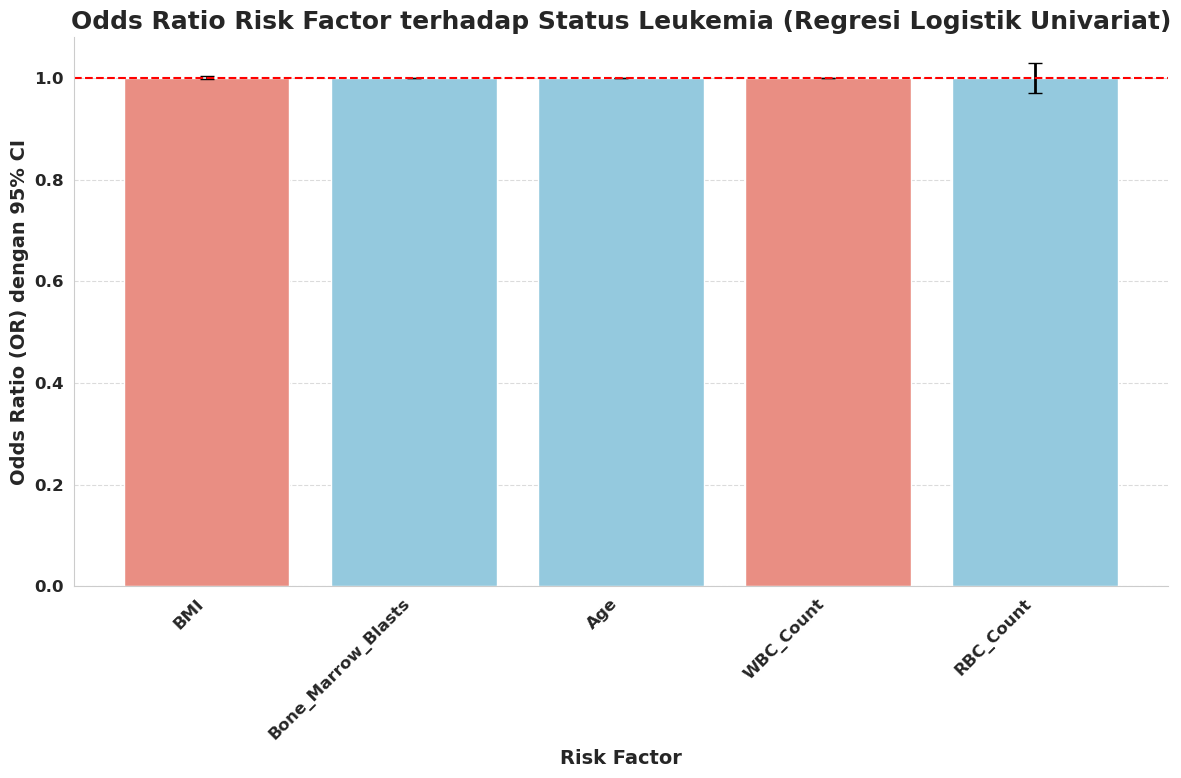

In [10]:
# visualize barplot for data
plt.figure(figsize=(12, 8)) # Ukuran figure landscape
colors = ['skyblue'] * len(risk_factor_cols) # Warna bar default

# iterate 
for index, row in df_visualize_univariate.iterrows(): # Loop iterasi baris di df_visualize_univariate
    if row['Odds Ratio'] < 1: # Cek kondisi Odds Ratio < 1 di SETIAP BARIS
        colors[index] = 'salmon' # Kalo kondisi terpenuhi, assign warna 'salmon' ke bar dengan index yang sesuai

bars = sns.barplot(x='Risk Factor', y='Odds Ratio', data=df_visualize_univariate, palette=colors) # Bar plot dengan custom colors
plt.errorbar(x=df_visualize_univariate['Risk Factor'], 
             y=df_visualize_univariate['Odds Ratio'],
             yerr = np.array([df_visualize_univariate['Odds Ratio'] - df_visualize_univariate['Lower CI'],
                 df_visualize_univariate['Upper CI'] - df_visualize_univariate['Odds Ratio']]),
             fmt='none', 
             ecolor='black', 
             capsize=5, 
             linewidth=2
             )
plt.axhline(1, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Risk Factor', fontweight='bold', fontsize=14)
plt.ylabel('Odds Ratio (OR) dengan 95% CI', fontweight='bold', fontsize=14)
plt.title('Odds Ratio Risk Factor terhadap Status Leukemia (Regresi Logistik Univariat)', fontweight='bold', fontsize=18)
plt.xticks(rotation=45, ha='right', fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(top=True, right=True, left=False, bottom=False) 
plt.tight_layout() 
plt.show()